# Discrete Rigid Contact


## Goal
Compare co-simulation with a monolithic Modelica reference for rigid wall contact, and show convergence as communication step size decreases.

## Model Map

![System Graph](figures/graphs/04_rigid_contact_graph.svg)

## Assumptions and Scope
- Rigid wall contact (event-driven)
- Fixed-step co-simulation; reference uses variable-step DASSL

## Prerequisites and Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

from OMPython import ModelicaSystem
from demos.ControlledPendulum.src.master_pendulum import MasterPendulum, FMUPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config

from syssimx import FMUComponent, System, SystemGraphVisualizer, Connection, EventConnection

## Discover FMUs

In [2]:
PLATFORM = sys.platform
demo_dir_path = Path().cwd() / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir


## Modelica Reference Simulation

We refer to the monolithic Modelica simulation as "Modelica" in the following. The simulation results are obtained by running the `RigidContact` example model in *OpenModelica* using the `OMPython` interface. The model can be found in the `demos/ControlledPendulum/src/modelica/ControlledPendulum/Examples/Contact/RigidContact.mo` package.

### PID without Integrator Reset on Contact

In [20]:
from OMPython import ModelicaSystem

reference = ModelicaSystem(fileName=str(package_path / "package.mo"),
                           modelName="ControlledPendulum.Examples.Contact.RigidContact")
reference.setParameters({'useReset': 'false'})
reference.buildModel()

simargs = {
    "stopTime": 6.0,
    "stepSize": 0.001
}

reference.simulate(simargs=simargs)

ref_sol_names = ('time', 'theta', 'theta_ref', 'theta_meas', 'pid.I_out', 'pendulum.contact')
ref_sol_noreset = {name: reference.getSolutions(name).flatten() for name in ref_sol_names}

[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").
[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


### PID with Integrator Reset on Contact

In [21]:
reference.setParameters({'useReset': 'true'})
reference.buildModel()
reference.simulate(simargs=simargs)
ref_sol_reset = {name: reference.getSolutions(name).flatten() for name in ref_sol_names}

[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


### Compare Modelica Results

The figure illustarates the **windup of the PID** controller's integrator state when the pendulum hits the wall. The error between the reference and measured angle adds up in the integrator.

When the reference position crosses the wall angle, the controller without integrator reset is not able to recover immediately, as the integrator state is large and needs to be unwound.

In contrast, the controller with integrator reset is able to recover immediately, as the integrator state is reset to zero at contact. There is no error left to unwind, and the controller can react immediately to the reference position crossing the wall angle.

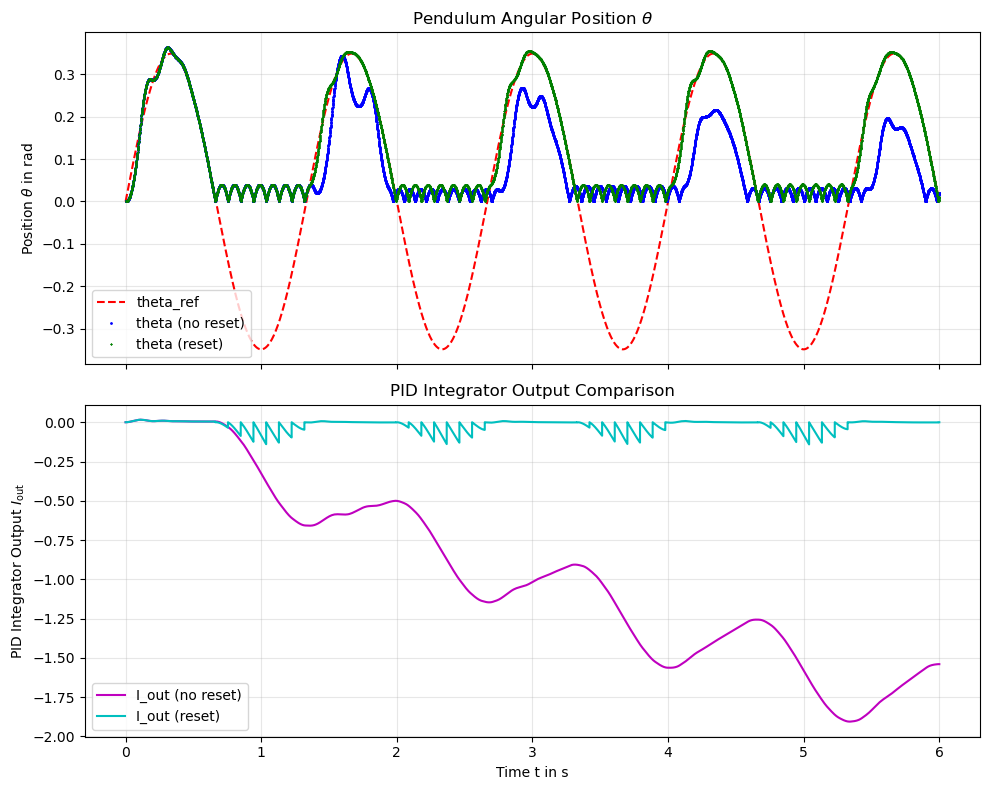

In [25]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot angles
axs[0].plot(ref_sol_noreset['time'], ref_sol_noreset['theta_ref'], 'r--', label='theta_ref')
axs[0].plot(ref_sol_noreset['time'], ref_sol_noreset['theta'], 'bo', label='theta (no reset)', markersize=1)
axs[0].plot(ref_sol_reset['time'], ref_sol_reset['theta'], 'gx', label='theta (reset)', markersize=1)
axs[0].set_ylabel(r'Position $\theta$ in rad')
axs[0].set_title(r'Pendulum Angular Position $\theta$')
axs[0].legend()
axs[0].grid(alpha=0.3)

# Plot integrator output
axs[1].plot(ref_sol_noreset['time'], ref_sol_noreset['pid.I_out'], 'm-', label='I_out (no reset)')
axs[1].plot(ref_sol_reset['time'], ref_sol_reset['pid.I_out'], 'c-', label='I_out (reset)')
axs[1].set_xlabel(r'Time t in s')
axs[1].set_ylabel(r'PID Integrator Output $I_{\text{out}}$')
axs[1].set_title('PID Integrator Output Comparison')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Instantiate FMU Components

In [6]:
def print_parameteres(component: FMUComponent):
    print(f"Parameters of {component.name}:")
    for name, param in component.parameters.items():
        if '.' not in name and param is not None:
            print(f"  - {name}: {param}")

### Setpoint

In [7]:
setpoint = FMUComponent(name="Setpoint",
                         fmu_path=fmu_paths['Trajectories']["SetPoint"],
                         group="Reference")
print_parameteres(setpoint)

Parameters of Setpoint:
  - amplitude: 0.3490658503988659 rad
  - frequency: 0.75 Hz
  - offset: 0.0 rad
  - phase: 0.0 rad


### PID Controller

In [8]:
class PIDController(FMUComponent):
    def __init__(self, name):
        fmu_path = fmu_paths['Controllers']['PIDControllerReset_euler']
        super().__init__(name=name, fmu_path=fmu_path, group="Controller")
        self.use_reset = False  # Flag to control whether to apply reset on event
    
    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        self.set_inputs({"resetI": True})
        self.do_step(t, 0)  # Perform a step to apply the resetI input
        self.set_inputs({"resetI": False})

pid = PIDController(name="PID")

print_parameteres(pid)

Parameters of PID:
  - Kd: 0.15
  - Ki: 4.0
  - Kp: 10.0
  - uMax: 1.0
  - uMin: -1.0


### Drive

In [9]:
drive = FMUComponent(name="Drive",
                     fmu_path=fmu_paths['Actuators']["DriveDynamic"],
                     group="Actuator")
print_parameteres(drive)

Parameters of Drive:
  - I_max: 10.0 A
  - L_arm: 0.000121 H
  - R_arm: 0.151 Ohm
  - V_rated: 48.0 V
  - V_supply: 16.0 V
  - eta: 0.85
  - gearRatio: 60.0
  - k_t: 0.03 m·N/A
  - n_0: 12916.0 1/min


### Pendulum

In [10]:
pendulum = FMUPendulum(name="Pendulum",solver="cvode")

def wall_contact_indicator(comp: FMUPendulum) -> float:
    theta = comp.get_outputs()["theta"]
    theta_wall = 0
    return theta - theta_wall

pendulum.add_event_indicator("wall_hit", func=wall_contact_indicator, direction=-1)

### Angle Sensor and Decoder

In [11]:
angle_sensor = FMUComponent(name="Angle Sensor",
                             fmu_path=fmu_paths['Sensors']['AngleSensor'],
                             group="Sensors")
print_parameteres(angle_sensor)

Parameters of Angle Sensor:
  - pot_range: 4.71238898038469 rad
  - r_bottom: 20000.0 Ohm
  - r_top: 80000.0 Ohm
  - samplePeriod: 0.01 s
  - theta_max: 0.45378560551852565 rad
  - theta_min: -0.45378560551852565 rad
  - v_adc: 3.0 V
  - v_pot: 5.0 V
  - nBits: 10


In [12]:
angle_decoder = FMUComponent(name="Angle Decoder",
                             fmu_path=fmu_paths['Sensors']['AngleDecoder'],
                             group="Signal Processing")

print_parameteres(angle_decoder)

Parameters of Angle Decoder:
  - pot_range: 4.71238898038469 rad
  - r_bottom: 20000.0 Ohm
  - r_top: 80000.0 Ohm
  - samplePeriod: 0.01 s
  - theta_max: 0.45378560551852565 rad
  - theta_min: -0.45378560551852565 rad
  - v_adc: 3.0 V
  - v_pot: 5.0 V
  - nBits: 10


## Define Connections

In [13]:
c1 = Connection(
    src_comp=setpoint.name,
    src_port=setpoint.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c21 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=angle_sensor.name,
    dst_port=angle_sensor.input_specs["theta"].name,
)

c22 = Connection(
    src_comp=angle_sensor.name,
    src_port=angle_sensor.output_specs["v_out"].name,
    dst_comp=angle_decoder.name,
    dst_port=angle_decoder.input_specs["v_in"].name,
)

c23 = Connection(
    src_comp=angle_decoder.name,
    src_port=angle_decoder.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c3 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c4 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c5 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

event_connection_1 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["omega_invert"].name,
)

event_connection_2 = EventConnection(
    src_comp=pendulum.name,
    src_port="wall_hit",
    dst_comp=pid.name,
    dst_port=pid.input_specs["resetI"].name,
)

connections = [c1, c21, c22, c23, c3, c4, c5]
components  = [setpoint, pid, drive, pendulum, angle_decoder, angle_sensor]

## Build and Initialize the System - No Reset

In [14]:
system = System(name="Pendulum System with Rigid Contact and PID Integrator Reset")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.add_event_connection(event_connection_1)
system.add_event_connection(event_connection_2)

system.initialize(t0=0.0)


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


## Visualize the System Graph

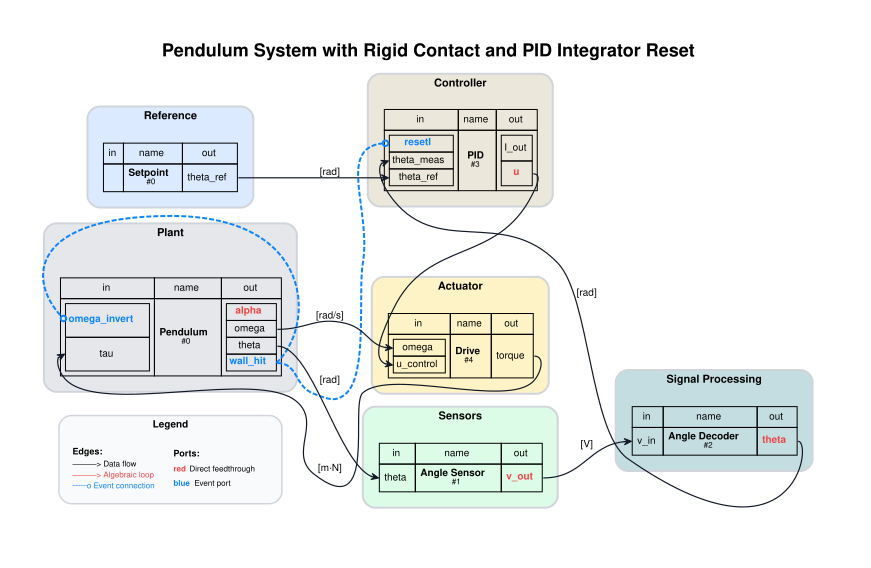

In [15]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

## Baseline Run

In [16]:
t = 0
t_end = 3
dt = 0.001

system.reset()
system.initialize(t0=t)
system.run(t0=t, tf=t_end, dt=dt)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

## Collect Results

In [17]:
history = system.get_history()

t_set_point = history[setpoint.name][0]
theta_ref = history[setpoint.name][1]['theta_ref']

t_pendulum = history[pendulum.name][0]
theta_pendulum = history[pendulum.name][1]['theta']

t_pid = history[pid.name][0]
I_out = history[pid.name][1]['I_out']

## Plot: Baseline Tracking vs Reference

The figure below compares the pendulum angle and PID integrator output from the co-simulation with the Modelica reference.

It can be observed that the co-simulation using the hybrid master algorithm closely follows the Modelica reference.

The contact events are captured accurately, and the integrator output shows the expected reset behavior at contact.

The deviations between the co-simulation and reference are minimal, but originate from the different numerical solvers and fixed vs variable step sizes.

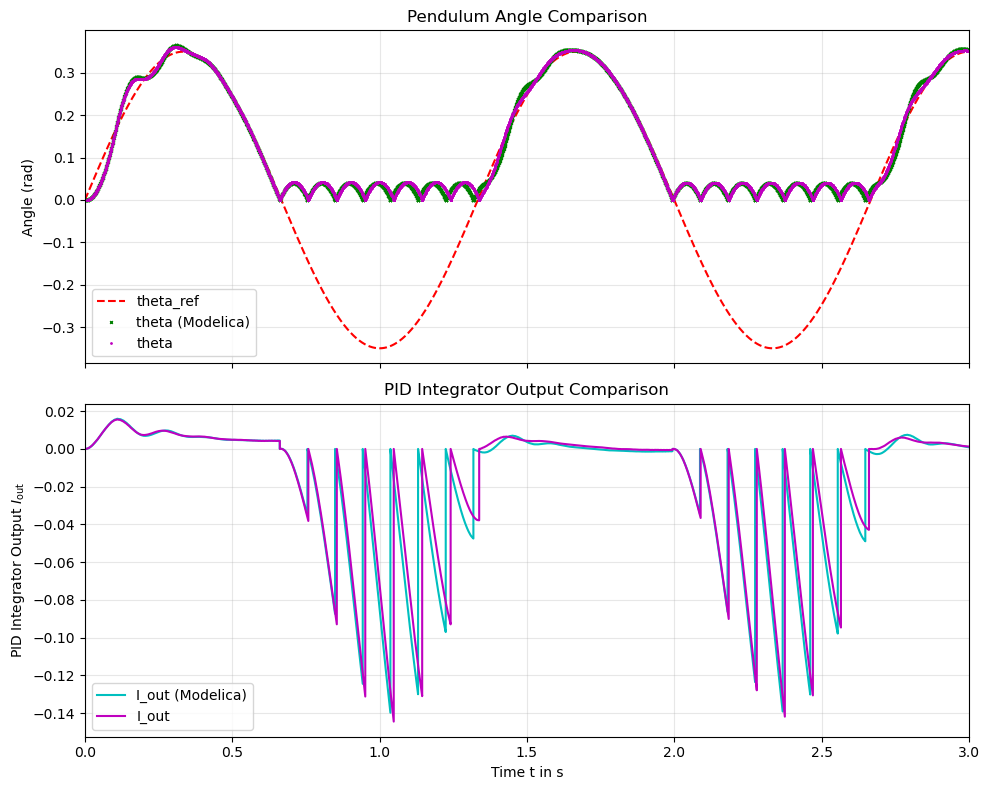

In [26]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot angles
axs[0].plot(ref_sol_noreset['time'], ref_sol_noreset['theta_ref'], 'r--', label='theta_ref')
axs[0].plot(ref_sol_reset['time'], ref_sol_reset['theta'], 'gx', label='theta (Modelica)', markersize=2)
axs[0].plot(t_pendulum, theta_pendulum, 'mo', label='theta', markersize=1)
axs[0].set_ylabel('Angle (rad)')
axs[0].set_title('Pendulum Angle Comparison')
axs[0].legend()
axs[0].grid(alpha=0.3)

# Plot integrator output
axs[1].plot(ref_sol_reset['time'], ref_sol_reset['pid.I_out'], 'c-', label='I_out (Modelica)')
axs[1].plot(t_pid, I_out, 'm-', label='I_out')
axs[1].set_xlabel(r'Time t in s')
axs[1].set_ylabel(r'PID Integrator Output $I_{\text{out}}$')
axs[1].set_title('PID Integrator Output Comparison')
axs[1].legend()
axs[1].grid(alpha=0.3)

axs[1].set_xlim(0, t_end)

plt.tight_layout()
plt.show()

## Summary
- Co-simulation trajectories converge toward the monolithic reference as `dt` decreases.
- Resetting the PID integrator reduces windup after contact events.